# Name: Baraka Mandi

# Q1: Implementing an RNN (LSTM) for Character-Level Text Generation

**Dataset** (downloaded automatically in the notebook):
- Tiny Shakespeare (~1.1 MB, default): https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt



**Requirements:** `pip install torch matplotlib`

In [1]:
import os
import time
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## Configuration

In [2]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
# DATA_URL = "https://www.gutenberg.org/cache/epub/1041/pg1041.txt"   # Shakespeare's Sonnets
DATA_PATH = "shakespeare.txt"
CHECKPOINT_PATH = "char_lstm_best.pt"

SEQ_LEN = 100        # characters per training sequence
BATCH_SIZE = 64
EMBED_DIM = 128      # ignored when USE_ONEHOT = True
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 2e-3
EPOCHS = 20
GRAD_CLIP = 5.0
VAL_FRACTION = 0.1
USE_ONEHOT = False   # True -> one-hot input vectors, False -> learned embeddings
SEED = 42

torch.manual_seed(SEED)

## Device: use GPU if available

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU
else:
    device = torch.device("cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: mps


## Step 1: Load the text dataset

In [4]:
def load_text(url: str, path: str) -> str:
    if not os.path.exists(path):
        print(f"Downloading dataset from {url} ...")
        urllib.request.urlretrieve(url, path)
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    print(f"Loaded {len(text):,} characters.")
    return text


text = load_text(DATA_URL, DATA_PATH)
print(text[:500])

Loaded 1,115,394 characters.
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## Step 2: Convert text into a sequence of characters

Each unique character gets an integer index. The model then either one-hot encodes these indices (`USE_ONEHOT = True`) or looks them up in a learned embedding table (default). Each training sample is a 100-character input, and its target is the same sequence shifted one character to the right, i.e. the next character at every position.

In [5]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}   # char -> index
itos = {i: ch for ch, i in stoi.items()}       # index -> char
print(f"Vocabulary size: {vocab_size}")
print(repr("".join(chars)))


def encode(s: str) -> list:
    return [stoi[c] for c in s if c in stoi]


def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)


data = torch.tensor(encode(text), dtype=torch.long)
split = int(len(data) * (1 - VAL_FRACTION))
train_data, val_data = data[:split], data[split:]
print(f"Train chars: {len(train_data):,} | Val chars: {len(val_data):,}")

Vocabulary size: 65
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
Train chars: 1,003,854 | Val chars: 111,540


In [6]:
class CharDataset(Dataset):
    """input = chars[i : i+L], target = chars[i+1 : i+L+1]"""

    def __init__(self, data: torch.Tensor, seq_len: int):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        chunk = self.data[start: start + self.seq_len + 1]
        return chunk[:-1], chunk[1:]


pin = device.type == "cuda"
train_loader = DataLoader(CharDataset(train_data, SEQ_LEN), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True, pin_memory=pin)
val_loader = DataLoader(CharDataset(val_data, SEQ_LEN), batch_size=BATCH_SIZE,
                        shuffle=False, drop_last=True, pin_memory=pin)

x, y = next(iter(train_loader))
print("Batch shapes:", x.shape, y.shape)
print("Input :", repr(decode(x[0][:50])))
print("Target:", repr(decode(y[0][:50])))

Batch shapes: torch.Size([64, 100]) torch.Size([64, 100])
Input : ' the demigod Authority\nMake us pay down for our of'
Target: 'the demigod Authority\nMake us pay down for our off'


## Step 3: Define the LSTM model

In [7]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers,
                 dropout, use_onehot=False):
        super().__init__()
        self.vocab_size = vocab_size
        self.use_onehot = use_onehot
        if use_onehot:
            input_dim = vocab_size
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim)
            input_dim = embed_dim
        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len) of character indices
        if self.use_onehot:
            x = F.one_hot(x, num_classes=self.vocab_size).float()
        else:
            x = self.embedding(x)                 # (batch, seq_len, embed_dim)
        out, hidden = self.lstm(x, hidden)        # (batch, seq_len, hidden)
        logits = self.fc(self.dropout(out))       # (batch, seq_len, vocab)
        return logits, hidden


model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS,
                 DROPOUT, USE_ONEHOT).to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                       factor=0.5, patience=2)

CharLSTM(
  (embedding): Embedding(65, 128)
  (lstm): LSTM(128, 512, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=65, bias=True)
)
Trainable parameters: 3,457,729


## Step 4: Train the model and generate text

`generate()` warms up the hidden state on a prompt, then repeatedly samples one character from the (temperature-scaled) softmax and feeds it back in as the next input.

In [8]:
@torch.no_grad()
def generate(model, start_text="ROMEO:", length=500, temperature=1.0, top_k=None):
    """temperature > 0 scales the logits before softmax; temperature <= 0 means greedy (argmax)."""
    model.eval()
    ids = encode(start_text) or [0]
    input_ids = torch.tensor([ids], dtype=torch.long, device=device)

    # Warm up the hidden state on the prompt
    logits, hidden = model(input_ids)
    logits = logits[:, -1, :]
    generated = list(start_text)

    for _ in range(length):
        if temperature <= 0:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            scaled = logits / temperature
            if top_k is not None:
                v, _ = torch.topk(scaled, top_k)
                scaled[scaled < v[:, [-1]]] = -float("inf")
            probs = F.softmax(scaled, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
        generated.append(itos[next_id.item()])
        logits, hidden = model(next_id, hidden)   # feed the sampled char back in
        logits = logits[:, -1, :]

    return "".join(generated)

In [9]:
def run_epoch(loader, train: bool) -> float:
    model.train(train)
    total_loss, n_batches = 0.0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits, _ = model(x)
            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)  # avoid exploding gradients
                optimizer.step()
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(n_batches, 1)

In [10]:
best_val = float("inf")
history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train loss {train_loss:.4f} | "
          f"val loss {val_loss:.4f} | {time.time() - t0:.1f}s")

    if val_loss < best_val:
        best_val = val_loss
        torch.save({"model_state": model.state_dict(), "stoi": stoi, "itos": itos,
                    "config": {"embed_dim": EMBED_DIM, "hidden_size": HIDDEN_SIZE,
                               "num_layers": NUM_LAYERS, "dropout": DROPOUT,
                               "use_onehot": USE_ONEHOT}},
                   CHECKPOINT_PATH)
        print(f"  -> saved best model (val loss {best_val:.4f})")

    # Short sample each epoch to watch the model improve
    print("  sample:", generate(model, "ROMEO:", 150, temperature=0.8).replace("\n", " | "))

Epoch 01/20 | train loss 2.2437 | val loss 1.8076 | 25.5s
  -> saved best model (val loss 1.8076)
  sample: ROMEO: | The couse a know-some preget: and the showly's serford their daid be our quils- | Whine for the comeo a sent but the geke her art | Lome puch have of you
Epoch 02/20 | train loss 1.6397 | val loss 1.6292 | 21.9s
  -> saved best model (val loss 1.6292)
  sample: ROMEO: | That our harfold for queen. My ladys that sheeh count in the their him; | The sound I seemfie say, | Your life: or sighlying danger the warle! I'll shall
Epoch 03/20 | train loss 1.5101 | val loss 1.5650 | 22.3s
  -> saved best model (val loss 1.5650)
  sample: ROMEO: | Here, and speak him with in my name, | Which not aathurs. I'll raid to have not the man. |  | CORIOLANUS: | O this best renown stalk perford, | With place he s
Epoch 04/20 | train loss 1.4457 | val loss 1.5263 | 21.9s
  -> saved best model (val loss 1.5263)
  sample: ROMEO: | Do, I cannot deep thiness of sabed with | In him here hath remem

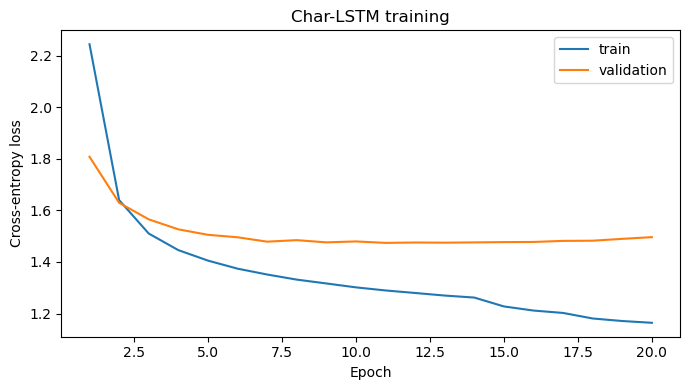

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history["train"]) + 1), history["train"], label="train")
plt.plot(range(1, len(history["val"]) + 1), history["val"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Char-LSTM training")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Load the best checkpoint and generate a longer passage
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
print(generate(model, "ROMEO:", 800, temperature=0.8))

ROMEO:
Nor with his friends, and take his sight!

LUCIO:
Then, sir, I for a little about a change.

HENRY BOLINGBROKE:
No, let him be here, and they should seek.

CORIOLANUS:
The curid of honour may in boot
Were winter of death should tell you well there?
Or there is his regard and blood,
Some fellow o' the most renown
As to change the aspiring imprisonment
With meet cannot leave a love before the breast.

KING RICHARD III:
What silver shall they will;
To mere your fortune speaks my clouds may well for God!
And bless me beguile mine, as now I were excuse,
We are to grace we'll thren thee to the good to crave.

KING RICHARD III:
If you not hear me; and where art thou mine made,
That says the bosom be an holy treasons of words.

JULIET:
How now, he has far grave like a king, where's a sick
And hul


## Step 5: Temperature scaling

In [12]:
# Numerical illustration: same logits, different temperatures
logits = torch.tensor([2.0, 1.0, 0.5, 0.1])
print("Toy logits = [2.0, 1.0, 0.5, 0.1]")
for T in [0.2, 0.5, 1.0, 1.5, 3.0]:
    p = F.softmax(logits / T, dim=-1)
    entropy = -(p * p.log()).sum().item()
    print(f"  T={T:<4} probs={[round(v, 3) for v in p.tolist()]}  entropy={entropy:.3f}")

Toy logits = [2.0, 1.0, 0.5, 0.1]
  T=0.2  probs=[0.993, 0.007, 0.001, 0.0]  entropy=0.046
  T=0.5  probs=[0.828, 0.112, 0.041, 0.019]  entropy=0.607
  T=1.0  probs=[0.575, 0.211, 0.128, 0.086]  entropy=1.121
  T=1.5  probs=[0.462, 0.237, 0.17, 0.13]  entropy=1.265
  T=3.0  probs=[0.35, 0.251, 0.213, 0.186]  entropy=1.356


In [14]:
# Compare generated text across temperatures
for T in [0.2, 0.5, 0.8, 1.0, 1.5]:
    print("\n" + "=" * 70)
    print(f"Temperature = {T}")
    print("=" * 70)
    print(generate(model, "ROMEO:", 400, temperature=T))


Temperature = 0.2
ROMEO:
The man that shall be so with the world and like a sea
And so that the consul to the seat of the common soul
That shall be so sound to the man of the truth,
And therefore the same that is so well that I will not so,
The son of the world that they are as the world.

KING RICHARD II:
The truth of his son and which should be so dead.

LUCIO:
What is the world and the consul?

CORIOLANUS:
I will not 

Temperature = 0.5
ROMEO:
Here is he that had not can speak not by the sun,
And make before my soul is the lies.

ROMEO:
The crown as the queen of wreath,
That thou hast consent and true heart to see your fortune
To fright thee so true windows are in the head.

PAULINA:
I will not be content to the world,
Who hath part of the fortunes with the way
A beast then be gone and thrown on the common court and her
And there in th

Temperature = 0.8
ROMEO:
I am where it will will not hear the fair fruit
That, fit and thought mortal stones, here in his conforture
In thy wrath h

### Explanation: the role of temperature scaling

At each step the model outputs a logit $z_i$ for every character, and softmax turns these into probabilities. Temperature $T$ divides the logits before the softmax:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

The ranking of characters never changes; only how peaked or flat the distribution is.

- **$T < 1$ (e.g. 0.2–0.5):** gaps between logits are stretched, so the most likely character dominates. Output is conservative, with correct spelling and common words, but repetitive and prone to loops.
- **$T = 1$:** samples from the distribution exactly as the model learned it, usually a good balance.
- **$T > 1$ (e.g. 1.5+):** the distribution flattens toward uniform, so rare characters are picked more often. Output is more diverse and surprising but has more misspellings, invented words and broken structure.

Temperature is a knob that trades **coherence for creativity** by controlling the entropy (randomness) of the sampling distribution, without retraining the model.